# Plotting routine for a timeseries

In [1]:
from operator import eq

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import cartopy.crs as ccrs
from scipy import stats
from scipy.special import sph_legendre_p

# Larger fonts everywhere (default labels were too small)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 110,
})

In [2]:
# Import and adjustment of the data
data_slabctr = xr.open_dataset(f"LessOzone_Real_Analysis/slabctr_3D_2000-2035.nc")        # slab control run
data         = xr.open_dataset(f"LessOzone_Real_Analysis/LessOzone_Real_3D_2000-2035.nc")  # our simulation
grid         = xr.open_dataset(f"LessOzone_Real_Analysis/icon_grid_G.nc")                  # triangular grid (for maps)


def to_datetime(ds):
    """Convert the YYYYMMDD float time axis into a proper datetime index."""
    strs = [str(int(d)) for d in ds["time"].values]
    iso  = [f"{s[:4]}-{s[4:6]}-{s[6:]}" for s in strs]
    return ds.assign_coords(time=pd.to_datetime(iso))


data_slabctr = to_datetime(data_slabctr)
data         = to_datetime(data)

# The control run carries an extra first month (Jan 2000) the simulation lacks.
data_slabctr = data_slabctr.isel(time=slice(1, None))

In [3]:
# Calculation of the means
datamean = data["ta"].sel(height=slice(1,10)).mean(dim=["ncells", "height"])-273.15
data_slabctr_mean = data_slabctr["ta"].sel(height=slice(1,10)).mean(dim=["ncells", "height"])-273.15

In [4]:
difference = datamean - data_slabctr_mean

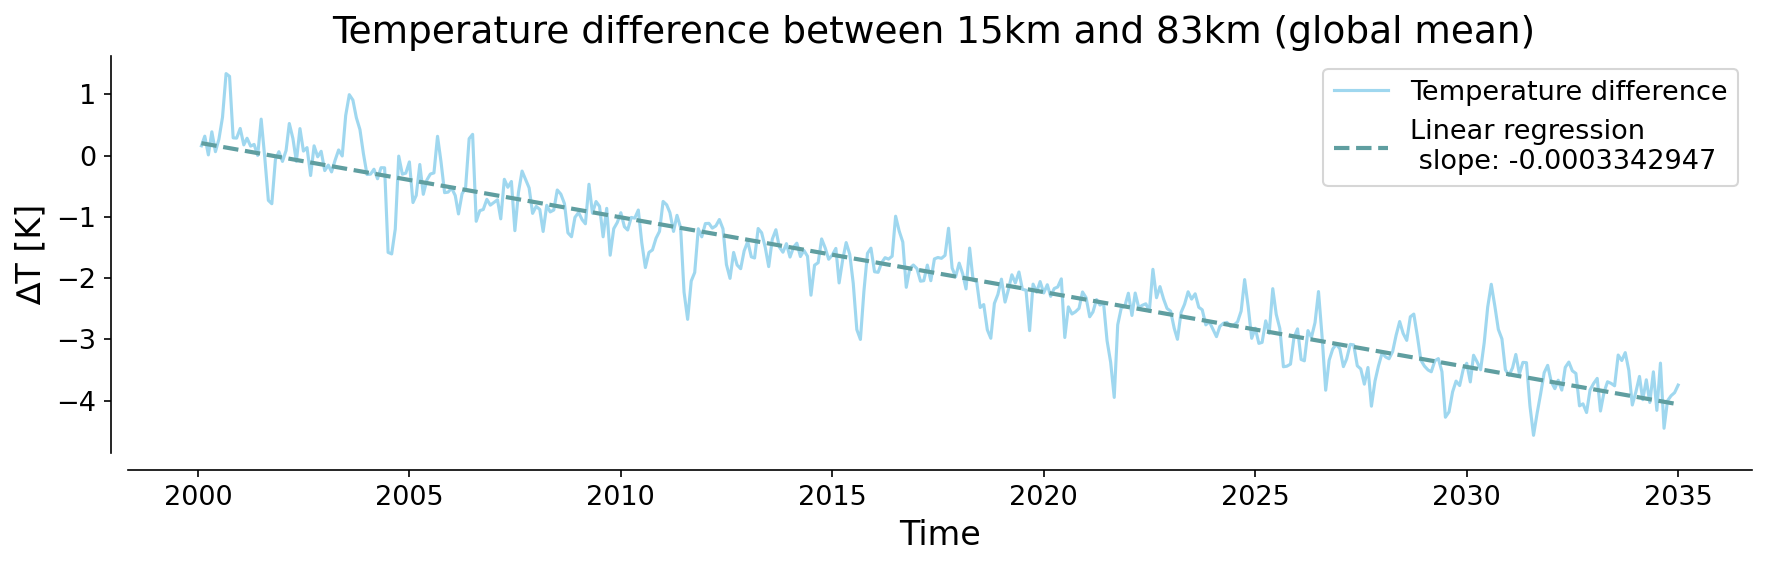

In [6]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

# Horizontal line for better interpretation of the trend
#ax.axhline(y=14, xmin=0, xmax=1, linestyle="--", color="black", alpha=1, linewidth=0.8)
"""
# no MCP
datamean.plot(ax=ax, color="tomato", label="no MCP", alpha=0.5)

x_num = mdates.date2num(datamean.time.values.astype("datetime64[ms]").astype("O"))
slope1, intercept, r, p, se = stats.linregress(x_num, datamean.values)
ax.plot(datamean.time.values, intercept + slope1 * x_num,
        color="tomato", linewidth=2, label=f"Trend no MCP \n slope: {round(slope1,10)}", linestyle="--", alpha=1)

# Control run
data_slabctr_mean.plot(ax=ax, color="skyblue", label="control run", alpha=0.5)

x_num = mdates.date2num(data_slabctr_mean.time.values.astype("datetime64[ms]").astype("O"))
slope2, intercept, r, p, se = stats.linregress(x_num, data_slabctr_mean.values)
ax.plot(data_slabctr_mean.time.values, intercept + slope2 * x_num,
        color="cadetblue", linewidth=2, label=f"Trend control run \n slope: {round(float(slope2),10)}", linestyle="--", alpha=1)"""

# Difference
difference.plot(ax=ax, color="skyblue", alpha=0.8, label="Temperature difference")

x_num = mdates.date2num(difference.time.values.astype("datetime64[ms]").astype("O"))
slope2, intercept, r, p, se = stats.linregress(x_num, difference.values)
ax.plot(difference.time.values, intercept + slope2 * x_num,
        color="cadetblue", linewidth=2, label=f"Linear regression \n slope: {round(float(slope2),10)}", linestyle="--", alpha=1)


# Marks the x-axis only every 5 years and inserts a vertical line there
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#ax.grid(axis="x", linestyle="--", color="black", alpha=1, linewidth=0.8)
ax.set_axisbelow(True)

# Adaption of the appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

plt.xticks()
#plt.yticks((11,12,13,14,15,16,17))
plt.title("Temperature difference between 15km and 83km (global mean) ")
plt.xlabel("Time")
plt.ylabel("∆T [K]")

plt.legend(
    loc='upper right',  # Standardposition
    bbox_to_anchor=(1.0, 1)  # (x, y) – hier 0 = links, 0.9 = 90% der y-Achse
)
plt.tight_layout()
#plt.savefig("Tempdifference_timeseries_ta_15kmto83km.png", dpi=300)
plt.show()

In [ ]:
*